In [1]:
import pandas as pd
import matplotlib.pyplot as plt

dfDef = pd.read_csv("../resources/gdpdef.csv")
dfDef.head()
dfDef['Year'] = dfDef['date'].str.split('-').str[0].astype(int)
arrDef = dfDef.set_index('Year')['gdpdef']
arrDef[2024] = (139.71495 / 136.41462) * arrDef[2023]
def gcam_deflator(value, from_year=2023, to_year=1975):
    return value * arrDef[to_year] / arrDef[from_year]

dfExc = pd.read_csv("../resources/DEXKOUS.csv")
dfExc['date'] = pd.to_datetime(dfExc['observation_date'])
dfExcAnnual = dfExc.groupby(dfExc['date'].dt.year)['DEXKOUS'].mean()

def krw_to_usd(year):
    return 1 / dfExcAnnual[year]

# Source

* Data Source:
    * [Ministry of Environment](https://eiec.kdi.re.kr/policy/callDownload.do?num=263662&filenum=1&dtime=20250227080122)
    * The 3rd National Energy Master Plan

* Implemented Input Files
    * `/input/policy/korea-2035/transportation/ZEV_charging_infra_cp.xml`
    * `/input/policy/korea-2035/transportation/ZEV_charging_infra_ep.xml`

# Subsidies for Charging Infrastructure

From the Ministry of Environment’s subsidy guidelines, we collected annual data on total charging infrastructure subsidies for both EVs and FCEVs. The total subsidies were averaged, and the average amount for each year was divided by the annual target number of electric vehicles to obtain the subsidy per vehicle. This per-vehicle subsidy was then converted into a performance-based subsidy using the assumptions specified in `basic_assumption.ipynb`. In the *Enhanced Ambition* scenario, the subsidy per unit of ZEV performance is assumed to be maintained. Detailed implementation steps are provided below.

## BEV

According to [the Ministry of Environment](https://eiec.kdi.re.kr/policy/callDownload.do?num=263662&filenum=1&dtime=20250227080122), the average total subsidy for BEV charging infrastructor is 447.57 billion KRW. We assume that this amount is distributed to the BEV target 4.2 million for 2030.

In [2]:
# unit: vehicles
target_2023 = 543_900
target_2024 = 684244
target_2018 = 55_756
target_2020 = 134_962
target_2030 = 4_200_000
target_2025 = target_2024 + (target_2030 - target_2024) * 1/6
target_2040 = 8_300_000
target_2035 = target_2030 + (target_2040 - target_2030) * (1/2)

dfProj = pd.DataFrame({
    'Year': [2018, 2020, 2023, 2025, 2030, 2035, 2040],
    '# of BEV': [target_2018, target_2020, target_2023, target_2025, target_2030, target_2035, target_2040]
})
numVehicles = dfProj[dfProj['Year'] >= 2025].set_index('Year')['# of BEV']
numVehicles

Year
2025    1.270203e+06
2030    4.200000e+06
2035    6.250000e+06
2040    8.300000e+06
Name: # of BEV, dtype: float64

In [3]:
subsidyTot = 447.57 * 1_000_000_000
# numVehicles = 684244
subsidyPerVehicle = subsidyTot / numVehicles / dfExcAnnual[2024] * gcam_deflator(1, from_year=2023, to_year=1990)
subsidyPerVehicle

Year
2025    125.346736
2030     37.908534
2035     25.474535
2040     19.182632
Name: # of BEV, dtype: float64

In [4]:
dfB = subsidyPerVehicle.reset_index()

In [5]:
# Medium truck
subsidyPerTkm = subsidyPerVehicle / (47 * 365 * 4.2)
subsidyPerTkm

Year
2025    0.001740
2030    0.000526
2035    0.000354
2040    0.000266
Name: # of BEV, dtype: float64

In [6]:
# Bus
subsidyPerPassKm = subsidyPerVehicle / 824767
subsidyPerPassKm

Year
2025    0.000152
2030    0.000046
2035    0.000031
2040    0.000023
Name: # of BEV, dtype: float64

In [7]:
# Car
subsidyPerPassKm = subsidyPerVehicle / (33 * 365 * 1.26)
subsidyPerPassKm

Year
2025    0.008259
2030    0.002498
2035    0.001679
2040    0.001264
Name: # of BEV, dtype: float64

## FCEV

(The total subsidy for FCEV charging infrastructure is (136.5 + 8.2) billion KRW in 2024-2025)[https://www.energy-news.co.kr/news/articleView.html?idxno=92606]. By 2024, 37557 FCEV was enrolled.

In [8]:
# unit: vehicles
target_2023 = 36989
target_2024 = 37557
target_2030 = 300000
target_2025 = target_2023 + (target_2030 - target_2024) * 1/6
target_2040 = 2900000
target_2035 = target_2030 + (target_2040 - target_2030) * (1/2)

dfProj = pd.DataFrame({
    'Year': [2018, 2020, 2023, 2024, 2025, 2030, 2035, 2040],
    '# of FCEV': [893, 10906, target_2023, target_2024, target_2025, target_2030, target_2035, target_2040]
})
numVehicles = dfProj[dfProj['Year'] >= 2025].set_index('Year')['# of FCEV']
numVehicles

Year
2025      80729.5
2030     300000.0
2035    1600000.0
2040    2900000.0
Name: # of FCEV, dtype: float64

In [9]:
subsidyTot = 136.5 * 1_000_000_000
# numVehicles = 37557
subsidyPerVehicle = subsidyTot / numVehicles / dfExcAnnual[2024] * gcam_deflator(1, from_year=2023, to_year=1990)
subsidyPerVehicle

Year
2025    601.486240
2030    161.858945
2035     30.348552
2040     16.744029
Name: # of FCEV, dtype: float64

In [10]:
dfF = subsidyPerVehicle.reset_index()

In [11]:
# Medium truck
subsidyPerTkm = subsidyPerVehicle / (47 * 365 * 4.2)
subsidyPerTkm

Year
2025    0.008348
2030    0.002246
2035    0.000421
2040    0.000232
Name: # of FCEV, dtype: float64

In [12]:
# Bus
subsidyPerPassKm = subsidyPerVehicle / 824767
subsidyPerPassKm

Year
2025    0.000729
2030    0.000196
2035    0.000037
2040    0.000020
Name: # of FCEV, dtype: float64

In [13]:
# Car
subsidyPerPassKm = subsidyPerVehicle / (33 * 365 * 1.26)
subsidyPerPassKm

Year
2025    0.039632
2030    0.010665
2035    0.002000
2040    0.001103
Name: # of FCEV, dtype: float64

In [14]:
dfEv = dfB.merge(dfF, on='Year', how='left')
dfEv.columns = ['Year', 'BEV', 'FCEV']
dfEv

,Year,BEV,FCEV
0,2025,125.346736,601.486240
1,2030,37.908534,161.858945
2,2035,25.474535,30.348552
3,2040,19.182632,16.744029


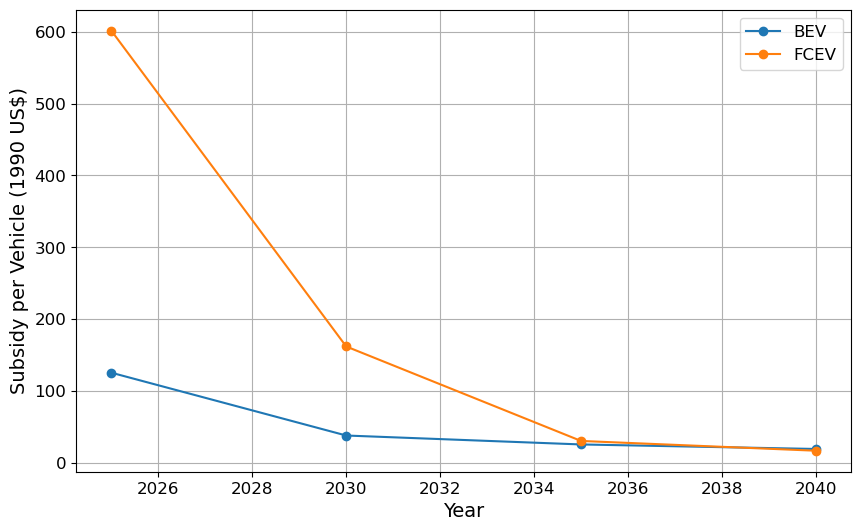

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(dfEv['Year'], dfEv['BEV'], label='BEV', marker='o')
plt.plot(dfEv['Year'], dfEv['FCEV'], label='FCEV', marker='o')

# plt.title('Subsidy per Vehicle Type Over Years', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Subsidy per Vehicle (1990 US$)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

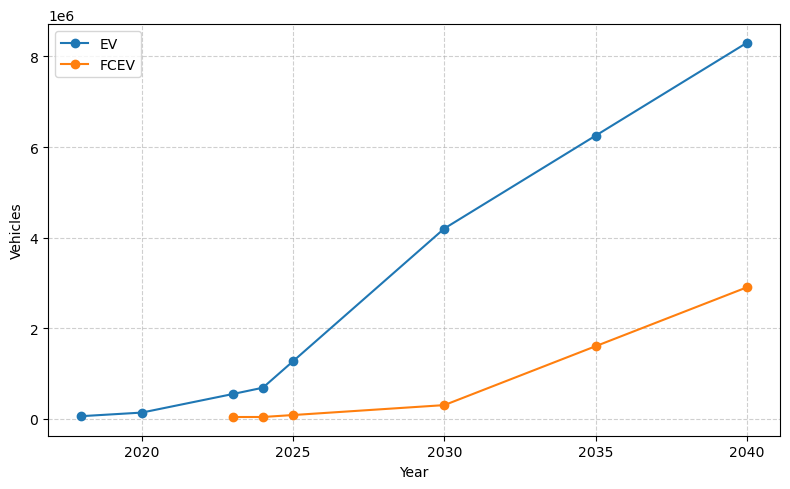

In [17]:
# --- EV targets (vehicles) ---
ev = {}
ev['2018'] = 55756
ev['2020'] = 134962
ev['2023'] = 543900
ev['2024'] = 684244
ev['2030'] = 4200000
ev['2040'] = 8300000
# Interpolations per user's formulas
ev['2025'] = ev['2024'] + (ev['2030'] - ev['2024']) * (1/6)
ev['2035'] = ev['2030'] + (ev['2040'] - ev['2030']) * (1/2)

# --- FCEV targets (vehicles) ---
fcev = {}
fcev['2023'] = 36989
fcev['2024'] = 37557
fcev['2030'] = 300000
fcev['2040'] = 2900000
# Interpolations per user's formulas
fcev['2025'] = fcev['2023'] + (fcev['2030'] - fcev['2024']) * (1/6)
fcev['2035'] = fcev['2030'] + (fcev['2040'] - fcev['2030']) * (1/2)

# Build tidy DataFrame
rows = []
for year_str, val in ev.items():
    rows.append({'Year': int(year_str), 'Technology': 'EV', 'Target (vehicles)': float(val)})
for year_str, val in fcev.items():
    rows.append({'Year': int(year_str), 'Technology': 'FCEV', 'Target (vehicles)': float(val)})
df = pd.DataFrame(rows)
df = df.sort_values(['Technology','Year'])

# Display a simple combined line chart
plt.figure(figsize=(8,5))
for tech, sub in df.groupby('Technology'):
    sub_sorted = sub.sort_values('Year')
    plt.plot(sub_sorted['Year'], sub_sorted['Target (vehicles)'], marker='o', label=tech)
# plt.title('ZEV Deployment Targets (Units)')
plt.xlabel('Year')
plt.ylabel('Vehicles')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()